In [348]:
#Bibliotecas utilizadas para a analise financeira de ativos
import yfinance as yf
import pandas as pd
import numpy as np
import investpy
import requests
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [349]:
# Transformar IPCA em série diária
ipca_diario = ipca.resample('D').ffill()  # 'D' = diário, preenche lacunas
ipca_diario = ipca_diario.squeeze()       # garante que seja Series 1D

# Agora criar o DataFrame combinado
df = pd.concat([ibov, sp500, vix, usdb, ouro, ipca_diario], axis=1)
df.columns = ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']
df.sort_index(inplace=True)
df = df.fillna(method='ffill')  # preenche lacunas restantes

print(df.head())


               IBOV        SP500        VIX  USDBRL         OURO  IPCA
2015-01-01      NaN          NaN        NaN  2.6542          NaN  1.24
2015-01-02  48512.0  2058.199951  17.790001  2.6532  1186.000000  1.24
2015-01-03  48512.0  2058.199951  17.790001  2.6532  1186.000000  1.24
2015-01-04  48512.0  2058.199951  17.790001  2.6532  1186.000000  1.24
2015-01-05  47517.0  2020.579956  19.920000  2.6912  1203.900024  1.24


C:\Users\joaop\AppData\Local\Temp\ipykernel_16364\2047856935.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')  # preenche lacunas restantes


In [350]:
#Calcular retornos logarítmicos
for ativo in df.columns:
    df[f'{ativo}_ret_diario'] = np.log(df[ativo] / df[ativo].shift(1))
    df[f'{ativo}_ret_mensal'] = np.log(df[ativo] / df[ativo].shift(21))
    df[f'{ativo}_ret_anual'] = np.log(df[ativo] / df[ativo].shift(252))

#alcular volatilidade
volatilidade = pd.DataFrame(index=['Diária','Mensal','Anual'], columns=['IBOV','SP500','VIX','USDBRL','OURO','IPCA'])
for ativo in ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']:
    volatilidade.loc['Diária', ativo] = df[f'{ativo}_ret_diario'].std()
    volatilidade.loc['Mensal', ativo] = df[f'{ativo}_ret_mensal'].std()
    volatilidade.loc['Anual', ativo] = df[f'{ativo}_ret_anual'].std()



c:\Users\joaop\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joaop\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joaop\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [351]:
#retorno diario 
ret_diario_cols = [f'{ativo}_ret_diario' for ativo in ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']]
correlacao_diaria = df[ret_diario_cols].corr()
print("Correlação Diária:")
display(correlacao_diaria)

Correlação Diária:


,IBOV_ret_diario,SP500_ret_diario,VIX_ret_diario,USDBRL_ret_diario,OURO_ret_diario,IPCA_ret_diario
IBOV_ret_diario,1.000000,0.527173,-0.390702,0.010331,0.056186,0.001158
SP500_ret_diario,0.527173,1.000000,-0.737741,-0.004896,0.026913,0.011905
VIX_ret_diario,-0.390702,-0.737741,1.000000,-0.017440,0.037952,-0.027615
USDBRL_ret_diario,0.010331,-0.004896,-0.017440,1.000000,-0.029493,0.024863
OURO_ret_diario,0.056186,0.026913,0.037952,-0.029493,1.000000,-0.010873
IPCA_ret_diario,0.001158,0.011905,-0.027615,0.024863,-0.010873,1.000000


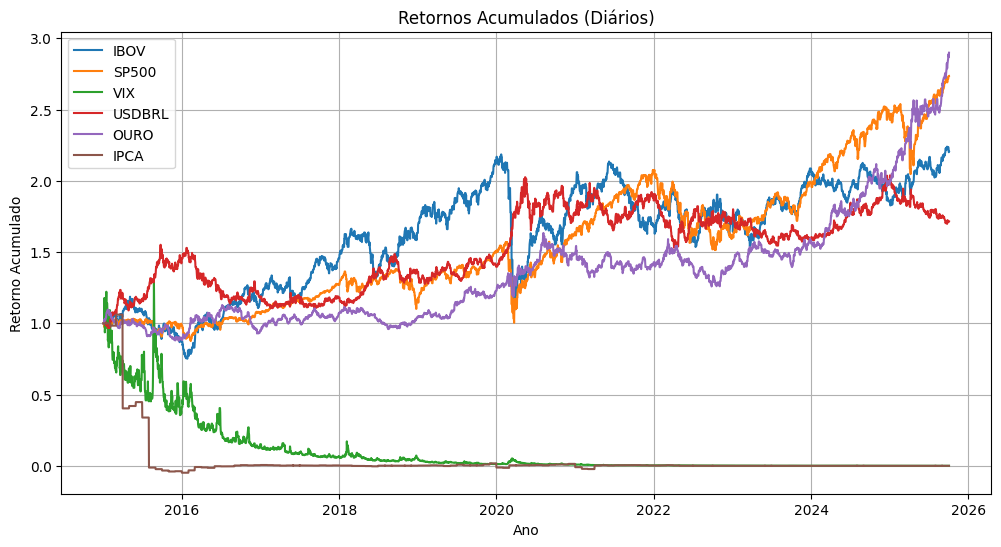

In [352]:
#Retorno acumulados 
ret_acumulado = (df[ret_diario_cols] + 1).cumprod()
plt.figure(figsize=(12,6))
for col in ret_acumulado.columns:
    plt.plot(ret_acumulado.index, ret_acumulado[col], label=col.replace('_ret_diario',''))
plt.title('Retornos Acumulados (Diários)')
plt.xlabel('Ano')
plt.ylabel('Retorno Acumulado')
plt.legend()
plt.grid(True)
plt.show()

In [353]:
# Definir nível de confiança
conf_level = 0.05  # 5%

# Lista de ativos
ativos = ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']

# Calcular VaR diário histórico
VaR_diario = {}
for ativo in ativos:
    retornos = df[f'{ativo}_ret_diario'].dropna()
    VaR_diario[ativo] = -np.percentile(retornos, conf_level*100)

VaR_diario = pd.Series(VaR_diario)
print("VaR Diário (5% de confiança):")
display(VaR_diario)


VaR Diário (5% de confiança):


IBOV      0.018097
SP500     0.013998
VIX       0.095351
USDBRL    0.013860
OURO      0.012788
IPCA     -0.000000
dtype: float64